# D3-04 Inventory flow assessment I - tracing intermediates

Run this notebook in the `bw` environment.

Here we use `edges` in a different way than in LCIA: instead of attaching impact factors to biosphere flows, we define **technosphere-to-technosphere** methods that simply count matched inventory exchanges.

That lets us answer two practical inventory questions:

- How much electricity is traced through the full supply chain of two hydrogen systems?
- How do two end-of-life systems split `1 kg` of waste across different treatment routes?


## Learning goals

After this notebook, you should be able to:

- build custom `edges` methods that target **technosphere intermediates** instead of biosphere flows
- use a technosphere-to-technosphere method to trace electricity through a full product system
- compare **direct foreground electricity use** to **total traced electricity** across the supply chain
- build a small family of route indicators to trace how waste is split across end-of-life treatment activities
- interpret grouped results and Sankey diagrams to explain why traced inventory-flow scores become large or route to specific destinations


## 1) Select two electricity-intensive hydrogen systems from the BAFU database

We compare two Swiss hydrogen routes that both depend strongly on grid electricity:

- `PEM electrolysis`
- `SOEC electrolysis`

Because both routes provide the same product but use different amounts of electricity, they are a good pair for an inventory-flow tracing example.

In [1]:
from pathlib import Path
from textwrap import fill
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import bw2data as bd
from edges import EdgeLCIA, SupplyChain

plt.style.use('seaborn-v0_8-whitegrid')

SYSTEM_COLORS = {
    'PEM electrolysis': '#0f766e',
    'SOEC electrolysis': '#ea580c',
}

TREATMENT_SYSTEM_COLORS = {
    'Wood frame core': '#92400e',
    'Wood-metal frame core': '#475569',
}

ROUTE_COLORS = {
    'Recycling': '#16a34a',
    'Municipal incineration': '#dc2626',
    'Sanitary landfill': '#f59e0b',
    'Construction waste landfill': '#0284c7',
    'Residual material landfill': '#6b7280',
}


/opt/homebrew/Caskroom/miniforge/base/envs/bw/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
bd.projects.set_current('barcelona-rlcia-2026')
bafu = bd.Database('bafu')

activities = {
    'PEM electrolysis': next(
        act for act in bafu
        if act['name'] == 'Hydrogen production, gaseous, 30 bar, from PEM electrolysis, from grid electricity'
        and act['location'] == 'CH'
    ),
    'SOEC electrolysis': next(
        act for act in bafu
        if act['name'] == 'Hydrogen production, gaseous, 1 bar, from SOEC electrolysis, from grid electricity'
        and act['location'] == 'CH'
    ),
}

pd.DataFrame([
    {
        'label': label,
        'name': act['name'],
        'location': act.get('location'),
        'reference product': act.get('reference product'),
        'unit': act.get('unit'),
    }
    for label, act in activities.items()
])

,label,name,location,reference product,unit
0,PEM electrolysis,"Hydrogen production, gaseous, 30 bar, from PEM...",CH,"Hydrogen production, gaseous, 30 bar, from PEM...",kilogram
1,SOEC electrolysis,"Hydrogen production, gaseous, 1 bar, from SOEC...",CH,"Hydrogen production, gaseous, 1 bar, from SOEC...",kilogram


### Inspect the direct foreground electricity inputs

Before tracing the full supply chain, first check the **direct** electricity exchanges in the foreground datasets themselves. These are the inputs you would see immediately by opening the activity, before following the rest of the electricity system upstream.

In [3]:
direct_rows = []

for label, act in activities.items():
    for exc in act.technosphere():
        if exc.input.get('unit') != 'kilowatt hour':
            continue
        direct_rows.append(
            {
                'activity': label,
                'supplier name': exc.input['name'],
                'supplier location': exc.input.get('location'),
                'amount': exc['amount'],
                'unit': exc.input.get('unit'),
            }
        )

direct_electricity = pd.DataFrame(direct_rows)
direct_electricity

,activity,supplier name,supplier location,amount,unit
0,PEM electrolysis,"Electricity, low voltage, at grid",CH,54.0,kilowatt hour
1,SOEC electrolysis,"Electricity, low voltage, at grid",CH,42.3,kilowatt hour


## 2) Load a technosphere-to-technosphere tracking method

The custom JSON file for this notebook uses a very simple rule:

- match **technosphere suppliers** whose `reference product` starts with `Electricity`
- keep only exchanges with unit `kilowatt hour`
- exclude supplier names containing `market` or `import`
- assign `CF = 1.0`

Because the characterization factor is `1.0`, every matched electricity exchange contributes exactly its own amount in `kWh`. The final score is therefore not an impact score. It is a **traced inventory-flow score in kWh**.

In [4]:
ASSETS_DIR = Path('assets/d3-04')
if not ASSETS_DIR.exists():
    ASSETS_DIR = Path('tutorials/DAY 3/assets/d3-04')

method_path = ASSETS_DIR / 'tracked_electricity_method.json'
tracked_method = json.loads(method_path.read_text())

pd.DataFrame([
    {
        'method': tracked_method['name'],
        'unit': tracked_method['unit'],
        'supplier rule': tracked_method['exchanges'][0]['supplier']['reference product'],
        'excluded terms': ', '.join(tracked_method['exchanges'][0]['supplier']['excludes']),
    }
])


,method,unit,supplier rule,excluded terms
0,Tracked electricity intermediates,kWh traced,Electricity,"market, import, voltage, mix"


## 3) Trace electricity through the full supply chain

Now we run `edges` with the custom method file on both hydrogen systems.

The main result we want is the **total traced electricity score** in `kWh traced / kg H2`. We also keep the full CF tables so we can later group them by supplier location and by consuming activity.

In [5]:
trace_tables = {}
comparison_rows = []

for label, act in activities.items():
    lca = EdgeLCIA(demand={act: 1}, method=str(method_path))
    lca.lci()
    lca.map_exchanges()
    lca.evaluate_cfs()
    lca.lcia()

    cf_table = lca.generate_cf_table(include_unmatched=False).copy()
    trace_tables[label] = cf_table

    direct_total = direct_electricity.loc[
        direct_electricity['activity'] == label,
        'amount',
    ].sum()

    comparison_rows.append(
        {
            'activity': label,
            'direct foreground electricity [kWh / kg H2]': direct_total,
            'total traced electricity [kWh / kg H2]': float(lca.score),
            'traced / direct multiplier': float(lca.score) / direct_total,
            'matched exchange rows': len(cf_table),
        }
    )

comparison = pd.DataFrame(comparison_rows)
comparison

,activity,direct foreground electricity [kWh / kg H2],total traced electricity [kWh / kg H2],traced / direct multiplier,matched exchange rows
0,PEM electrolysis,54.0,75.831563,1.404288,4849
1,SOEC electrolysis,42.3,60.307907,1.425719,4849


### Inspect the matched rows for one system

The PEM table below shows what the method is actually counting. Each row is a matched electricity exchange somewhere in the supply chain, and the `impact` column is simply the matched amount in `kWh` because the method uses `CF = 1.0`.

In [6]:
pem_preview = trace_tables['PEM electrolysis'].copy()
pem_preview = pem_preview.sort_values('impact', ascending=False)
preview_columns = [
    column for column in [
        'supplier name',
        'supplier location',
        'consumer name',
        'consumer location',
        'amount',
        'CF',
        'impact',
    ]
    if column in pem_preview.columns
]

pem_preview[preview_columns].head(12)

,supplier name,supplier location,consumer name,consumer location,amount,CF,impact
1866,"Electricity, nuclear, at power plant pressure ...",FR,Electricity mix,CH,11.933822,1.0,11.933822
2559,"Electricity, hydropower, net, at reservoir pow...",CH,Electricity mix,CH,8.738207,1.0,8.738207
2564,"Electricity, hydropower, at run-of-river power...",CH,"Electricity, hydropower, at run-of-river power...",CH,5.950862,1.0,5.950862
2569,"Electricity, hydropower, at run-of-river power...",CH,Electricity mix,CH,5.900160,1.0,5.900160
1835,"Electricity, nuclear, at power plant pressure ...",CH,Electricity mix,CH,5.133474,1.0,5.133474
1933,"Electricity, nuclear, at power plant boiling w...",CH,Electricity mix,CH,4.616035,1.0,4.616035
2563,"Electricity, hydropower, at run-of-river power...",RER,"Electricity, hydropower, at run-of-river power...",RER,4.274649,1.0,4.274649
2631,"Electricity, hydropower, at run-of-river power...",RER,Electricity mix,CH,3.932662,1.0,3.932662
4327,"Electricity, at wind farm",RER,Electricity mix,CH,3.878175,1.0,3.878175
4385,"Electricity, at 100MW wind farm, onshore, 2.3M...",RER,"Electricity, at wind farm",RER,2.059142,1.0,2.059142


## 4) Compare the traced electricity results

The next figure answers four complementary questions:

- how large is the gap between **direct** and **traced** electricity?
- in which **supplier locations** is the traced electricity generated?
- which **consumer activities** dominate the electricity demand of each hydrogen route?

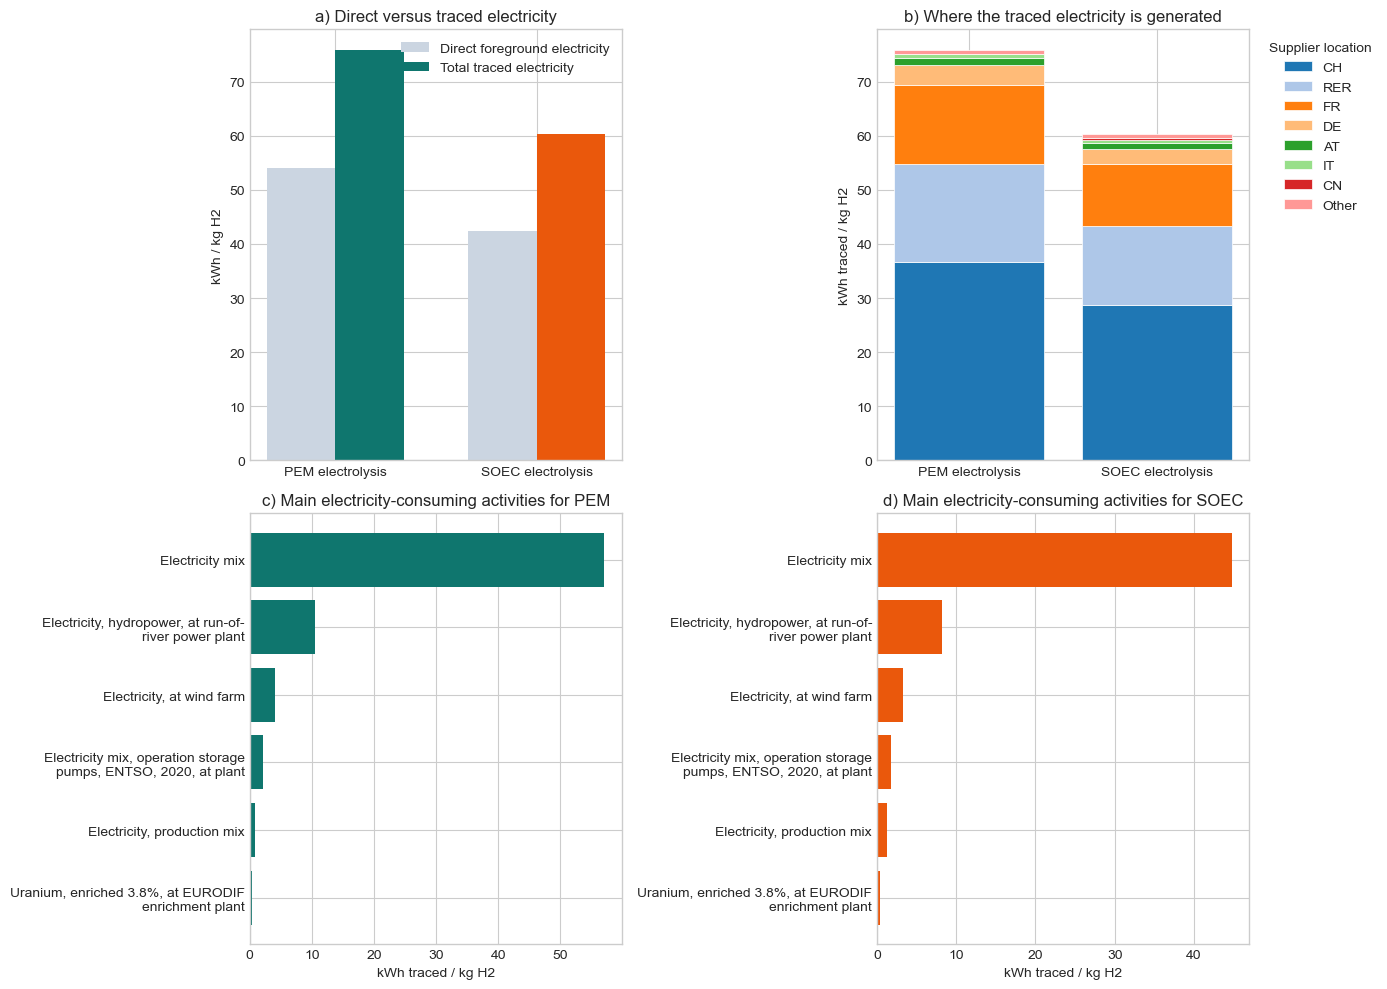

In [7]:
location_rows = []

for label, cf_table in trace_tables.items():
    grouped = (
        cf_table.groupby('supplier location', dropna=False, as_index=False)['impact']
        .sum()
        .sort_values('impact', ascending=False)
    )
    grouped['activity'] = label
    location_rows.append(grouped)

location_contributions = pd.concat(location_rows, ignore_index=True)
location_contributions['supplier location'] = location_contributions['supplier location'].fillna('Unknown')

top_locations = (
    location_contributions.groupby('supplier location')['impact']
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
    .tolist()
)

location_plot = location_contributions.copy()
location_plot['supplier location'] = location_plot['supplier location'].where(
    location_plot['supplier location'].isin(top_locations),
    'Other',
)
location_plot = (
    location_plot.groupby(['activity', 'supplier location'], as_index=False)['impact']
    .sum()
)

location_order = top_locations + ['Other']
location_palette = {
    location: color
    for location, color in zip(location_order, plt.cm.tab20.colors[: len(location_order)])
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# a) Direct versus traced electricity.
ax = axes[0, 0]
x = np.arange(len(comparison))
width = 0.34
ax.bar(
    x - width / 2,
    comparison['direct foreground electricity [kWh / kg H2]'],
    width,
    color='#cbd5e1',
    edgecolor='none',
    label='Direct foreground electricity',
)
ax.bar(
    x + width / 2,
    comparison['total traced electricity [kWh / kg H2]'],
    width,
    color=[SYSTEM_COLORS[label] for label in comparison['activity']],
    edgecolor='none',
    label='Total traced electricity',
)
ax.set_xticks(x)
ax.set_xticklabels(comparison['activity'])
ax.set_ylabel('kWh / kg H2')
ax.set_title('a) Direct versus traced electricity')
ax.legend(frameon=False)

# b) Supplier-location contributions.
ax = axes[0, 1]
bottom = np.zeros(len(comparison))
for location in location_order:
    values = []
    for label in comparison['activity']:
        match = location_plot.loc[
            (location_plot['activity'] == label)
            & (location_plot['supplier location'] == location),
            'impact',
        ]
        values.append(float(match.iloc[0]) if len(match) else 0.0)
    ax.bar(
        comparison['activity'],
        values,
        bottom=bottom,
        color=location_palette[location],
        edgecolor='white',
        linewidth=0.5,
        label=location,
    )
    bottom += np.array(values)
ax.set_ylabel('kWh traced / kg H2')
ax.set_title('b) Where the traced electricity is generated')
ax.legend(title='Supplier location', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# c) Top consumer activities for PEM.
ax = axes[1, 0]
pem_consumers = (
    trace_tables['PEM electrolysis']
    .groupby('consumer name', as_index=False)['impact']
    .sum()
    .sort_values('impact', ascending=False)
    .head(6)
    .iloc[::-1]
)
ax.barh(
    [fill(name, 38) for name in pem_consumers['consumer name']],
    pem_consumers['impact'],
    color=SYSTEM_COLORS['PEM electrolysis'],
)
ax.set_xlabel('kWh traced / kg H2')
ax.set_title('c) Main electricity-consuming activities for PEM')

# d) Top consumer activities for SOEC.
ax = axes[1, 1]
soec_consumers = (
    trace_tables['SOEC electrolysis']
    .groupby('consumer name', as_index=False)['impact']
    .sum()
    .sort_values('impact', ascending=False)
    .head(6)
    .iloc[::-1]
)
ax.barh(
    [fill(name, 38) for name in soec_consumers['consumer name']],
    soec_consumers['impact'],
    color=SYSTEM_COLORS['SOEC electrolysis'],
)
ax.set_xlabel('kWh traced / kg H2')
ax.set_title('d) Main electricity-consuming activities for SOEC')

plt.tight_layout()
plt.show()

### Interpretation

A direct foreground input of `54 kWh` for PEM does **not** mean the total electricity-related inventory burden stops at `54 kWh`.

The traced score becomes much larger because the notebook is counting all matched electricity exchanges upstream as well, including:

- low-, medium-, and high-voltage transformation stages
- electricity mixes and generation layers behind those grids
- additional electricity used in background equipment and materials

## 5) Use a Sankey diagram to explain the PEM result

A Sankey diagram is useful here because it shows the sequence of upstream stages that turn a `54 kWh` direct input into a much larger traced electricity score.

We keep the Sankey focused by:

- tracing only the `PEM` route
- stopping after `4` levels
- using a `1%` cutoff of the total traced score
- collapsing market layers to reduce clutter

In [8]:
pem_supply_chain = SupplyChain(
    activity=activities['PEM electrolysis'],
    method=str(method_path),
    amount=1,
    level=8,
    cutoff=0.01,
    cutoff_basis='total',
    collapse_markets=True,
)

pem_total_score = pem_supply_chain.bootstrap()
pem_supply_df, _, _ = pem_supply_chain.calculate()


Finding direct matches        [1/5]


Saved Sankey to D3-04_pem_electricity_sankey.html


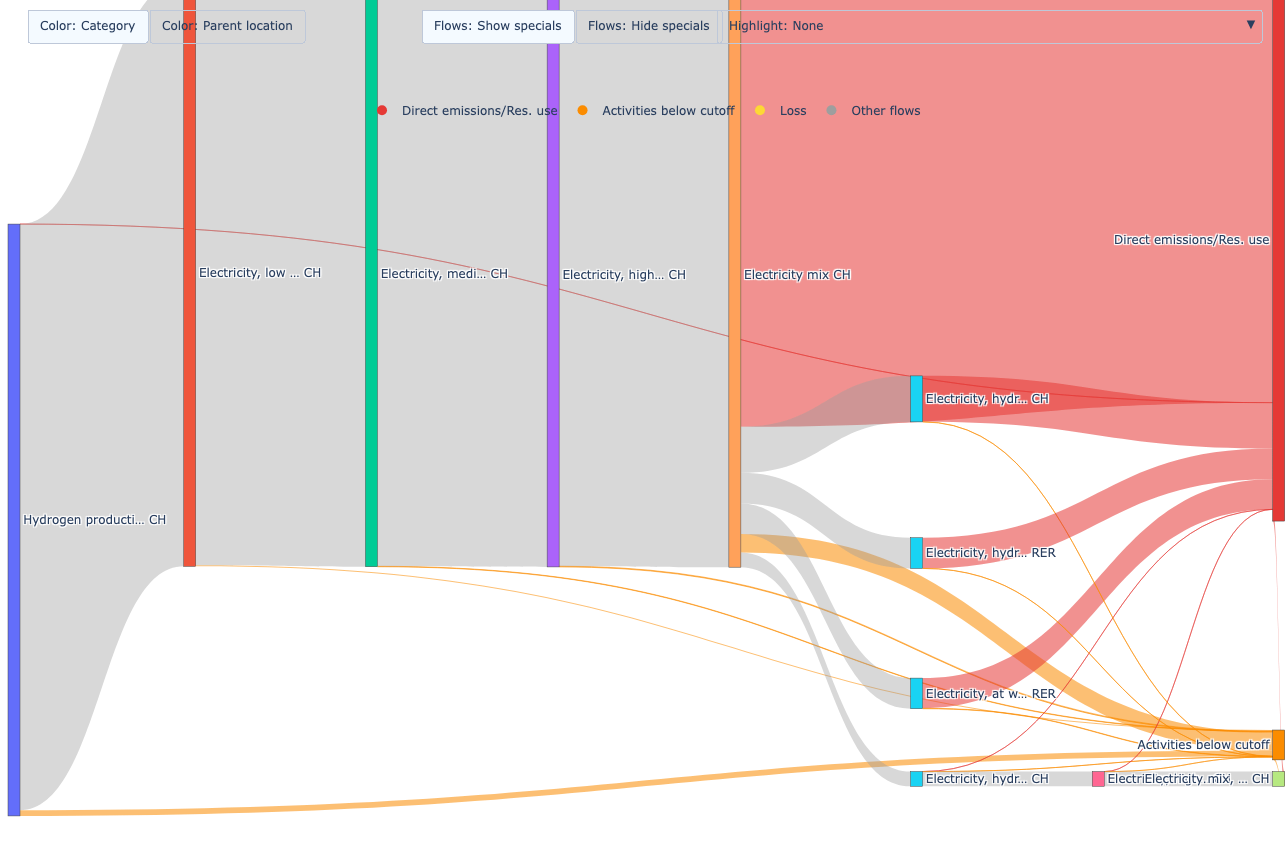

In [9]:
NOTEBOOK_DIR = Path('.')

sankey_path = NOTEBOOK_DIR / 'D3-04_pem_electricity_sankey.html'

pem_sankey = pem_supply_chain.plot_sankey(
    pem_supply_df,
    width_max=1600,
    height_max=850,
    node_instance_mode='by_parent',
    node_thickness=12,
    node_pad=8,
)

pem_sankey.write_html(sankey_path, include_plotlyjs='cdn')
print(f'Saved Sankey to {sankey_path}')
pem_sankey

## Checkpoint

Which route has the lower total traced electricity score, and what are the two clearest reasons visible in the tables and plots above?

Use the summary table and the Sankey result to support your answer.

In [10]:
# TODO
# 1. Identify the route with the lower traced electricity score.
# 2. Compare its direct foreground electricity input to the other route.
# 3. Use the top consumer activities or the Sankey to explain one upstream reason for the difference.

In [11]:
checkpoint_answer = comparison[[
    'activity',
    'direct foreground electricity [kWh / kg H2]',
    'total traced electricity [kWh / kg H2]',
    'traced / direct multiplier',
]].sort_values('total traced electricity [kWh / kg H2]')

checkpoint_answer

,activity,direct foreground electricity [kWh / kg H2],total traced electricity [kWh / kg H2],traced / direct multiplier
1,SOEC electrolysis,42.3,60.307907,1.425719
0,PEM electrolysis,54.0,75.831563,1.404288


## 6) Build a small library of material-tracking indicators

We can use the same technosphere-to-technosphere idea to trace **material-related intermediates** instead of electricity or waste-treatment routes.

Here we define a short list of simple, name-based indicators for:

- `wood`
- `steel`
- `aluminium`
- `concrete`

Each indicator uses `CF = 1.0` and matches technosphere suppliers whose **reference product** contains the chosen material keyword, with a `kilogram` unit. We also exclude generic terms such as `market`, `import`, `transport`, `disposal`, and `treatment`.

These are intentionally simple teaching indicators. They should be read as **traced material-related burdens** in kilograms, not as exact bills of materials.


In [12]:
material_method_paths = {
    'Wood': ASSETS_DIR / 'tracked_wood_method.json',
    'Steel': ASSETS_DIR / 'tracked_steel_method.json',
    'Aluminium': ASSETS_DIR / 'tracked_aluminium_method.json',
    'Concrete': ASSETS_DIR / 'tracked_concrete_method.json',
}

material_method_summary = []
for label, path in material_method_paths.items():
    method = json.loads(path.read_text())
    supplier_rule = method['exchanges'][0]['supplier']
    material_method_summary.append(
        {
            'indicator': label,
            'method': method['name'],
            'unit': method['unit'],
            'reference product rule': supplier_rule['reference product'],
            'excluded terms': ', '.join(supplier_rule['excludes']),
        }
    )

pd.DataFrame(material_method_summary)


,indicator,method,unit,reference product rule,excluded terms
0,Wood,Tracked wood intermediates,kg traced,wood,"market, import, transport, disposal, treatment"
1,Steel,Tracked steel intermediates,kg traced,steel,"market, import, transport, disposal, treatment"
2,Aluminium,Tracked aluminium intermediates,kg traced,aluminium,"market, import, transport, disposal, treatment"
3,Concrete,Tracked concrete intermediates,kg traced,concrete,"market, import, transport, disposal, treatment"


### Compare the traced material burdens for PEM and SOEC

We apply the four material indicators to the same hydrogen systems used in the electricity example.

The left panel keeps the traced burdens on their original scale. The right panel rescales each system to `100%` so that the relative material pattern becomes easier to compare.


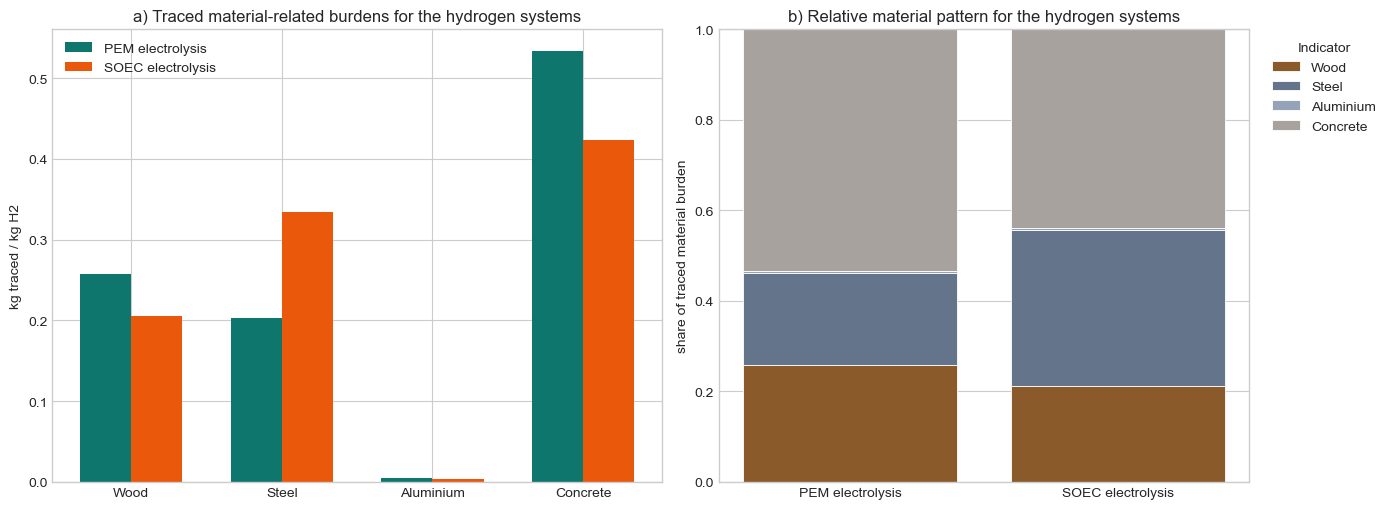

material,Wood,Steel,Aluminium,Concrete
activity,,,,
PEM electrolysis,0.2572,0.2032,0.0045,0.5339
SOEC electrolysis,0.2051,0.3337,0.0037,0.4238


In [13]:
material_trace_tables = {}
material_rows = []
material_order = list(material_method_paths)

for activity_label, act in activities.items():
    for material_label, path in material_method_paths.items():
        lca = EdgeLCIA(demand={act: 1}, method=str(path))
        lca.lci()
        lca.map_exchanges()
        lca.evaluate_cfs()
        lca.lcia()

        cf_table = lca.generate_cf_table(include_unmatched=False).copy()
        material_trace_tables[(activity_label, material_label)] = cf_table

        material_rows.append(
            {
                'activity': activity_label,
                'material': material_label,
                'score [kg traced]': float(lca.score),
                'matched exchange rows': len(cf_table),
            }
        )

material_scores = pd.DataFrame(material_rows)
material_pivot = (
    material_scores
    .pivot(index='activity', columns='material', values='score [kg traced]')
    .reindex(index=list(activities), columns=material_order)
)
material_shares = material_pivot.div(material_pivot.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={'width_ratios': [1.15, 1.0]})

# a) Absolute traced material burdens.
ax = axes[0]
x = np.arange(len(material_order))
width = 0.34
for offset, activity_label in zip([-width / 2, width / 2], activities):
    values = material_pivot.loc[activity_label, material_order].to_numpy(dtype=float)
    ax.bar(
        x + offset,
        values,
        width,
        label=activity_label,
        color=SYSTEM_COLORS[activity_label],
        edgecolor='none',
    )
ax.set_xticks(x)
ax.set_xticklabels(material_order)
ax.set_ylabel('kg traced / kg H2')
ax.set_title('a) Traced material-related burdens for the hydrogen systems')
ax.legend(frameon=False)

# b) Normalized material shares.
ax = axes[1]
bottom = np.zeros(len(activities))
material_colors = {
    'Wood': '#8b5a2b',
    'Steel': '#64748b',
    'Aluminium': '#94a3b8',
    'Concrete': '#a8a29e',
}
for material_label in material_order:
    values = material_shares.loc[list(activities), material_label].to_numpy(dtype=float)
    ax.bar(
        list(activities),
        values,
        bottom=bottom,
        color=material_colors[material_label],
        edgecolor='white',
        linewidth=0.6,
        label=material_label,
    )
    bottom += values
ax.set_ylim(0, 1.0)
ax.set_ylabel('share of traced material burden')
ax.set_title('b) Relative material pattern for the hydrogen systems')
ax.legend(title='Indicator', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

material_pivot.round(4)


### Build one Sankey per material for the PEM route

A single `CF = 1.0` tracer is already enough to build a Sankey diagram. The loop below creates one Sankey per material indicator for `PEM electrolysis` and saves each one as an HTML file next to the notebook.

This is useful when you want to inspect one material family at a time without overloading a single figure.


In [14]:
pem_material_supply_chains = {}
pem_material_sankey_paths = {}
pem_material_summaries = []

for material_label, path in material_method_paths.items():
    supply_chain = SupplyChain(
        activity=activities['PEM electrolysis'],
        method=str(path),
        amount=1,
        level=5,
        cutoff=0.005,
        cutoff_basis='total',
        collapse_markets=True,
    )

    total_score = supply_chain.bootstrap()
    supply_df, _, _ = supply_chain.calculate()

    sankey_path = NOTEBOOK_DIR / f"D3-04_pem_{material_label.lower()}_sankey.html"
    sankey_figure = supply_chain.plot_sankey(
        supply_df,
        width_max=1500,
        height_max=850,
        node_instance_mode='by_parent',
        node_thickness=12,
        node_pad=8,
    )
    sankey_figure.write_html(sankey_path, include_plotlyjs='cdn')

    pem_material_supply_chains[material_label] = supply_df
    pem_material_sankey_paths[material_label] = sankey_path
    pem_material_summaries.append(
        {
            'material': material_label,
            'score [kg traced / kg H2]': float(total_score),
            'rows in Sankey table': len(supply_df),
            'saved HTML': str(sankey_path),
        }
    )

pd.DataFrame(pem_material_summaries).sort_values('score [kg traced / kg H2]', ascending=False)


Finding direct matches        [1/5]
Finding direct matches        [1/5]
Finding direct matches        [1/5]
Finding direct matches        [1/5]


,material,score [kg traced / kg H2],rows in Sankey table,saved HTML
3,Concrete,0.533904,44,D3-04_pem_concrete_sankey.html
0,Wood,0.257213,41,D3-04_pem_wood_sankey.html
1,Steel,0.203212,82,D3-04_pem_steel_sankey.html
2,Aluminium,0.004490,76,D3-04_pem_aluminium_sankey.html


### Interpretation

These material indicators stay deliberately simple. They are useful to show how `edges` can trace selected families of technosphere intermediates through a supply chain, but they are still only as good as their name-based matching rules.

The next section uses the same general logic in a different way: instead of tracing material-related intermediates through the hydrogen systems, we trace end-of-life treatment routes that are already embedded inside two untreated window-frame product systems.


## 7) Build a second example: trace end-of-life routes from untreated window-frame cores

The electricity example followed one intermediate flow through the supply chain. We can use the same `CF = 1.0` idea to answer a different inventory question: **how are the main material fractions of a product system routed into end-of-life treatment activities?**

For this second case, we use two untreated frame-core datasets from `bafu`:

- `Window frame, wood, w/o surface treatment, m2 visible, at plant`
- `Window frame, wood-metal, w/o surface treatment, m2 visible, at plant`

These datasets are useful teaching examples because they already contain direct `Disposal...` and `Treatment...` technosphere exchanges. In other words, the end-of-life assumptions are already embedded inside the product system. They are also used upstream by painted or varnished window-frame variants, so they are not isolated toy activities.

We will compare five route indicators from `assets/d3-04/`:

- `recycling`
- `municipal incineration`
- `sanitary landfill`
- `construction waste landfill`
- `residual material landfill`

The resulting scores should be read as **traced routed burdens per m² frame core**, not as strict mass balances.


In [15]:
window_frame_specs = {
    'Wood frame core': {
        'activity': next(
            act for act in bafu
            if act['name'] == 'Window frame, wood, w/o surface treatment, m2 visible, at plant'
            and act['location'] == 'CH'
        ),
    },
    'Wood-metal frame core': {
        'activity': next(
            act for act in bafu
            if act['name'] == 'Window frame, wood-metal, w/o surface treatment, m2 visible, at plant'
            and act['location'] == 'CH'
        ),
    },
}

for spec in window_frame_specs.values():
    spec['downstream_uses'] = list(spec['activity'].upstream())

route_method_paths = {
    'Recycling': ASSETS_DIR / 'tracked_recycling_method.json',
    'Municipal incineration': ASSETS_DIR / 'tracked_municipal_incineration_method.json',
    'Sanitary landfill': ASSETS_DIR / 'tracked_sanitary_landfill_method.json',
    'Construction waste landfill': ASSETS_DIR / 'tracked_construction_landfill_method.json',
    'Residual material landfill': ASSETS_DIR / 'tracked_residual_landfill_method.json',
}

window_frame_systems = pd.DataFrame([
    {
        'system': label,
        'activity': spec['activity']['name'],
        'unit': spec['activity']['unit'],
        'used downstream by [datasets]': len(spec['downstream_uses']),
        'example downstream variants': '; '.join(
            sorted({exc.output['name'] for exc in spec['downstream_uses']})[:3]
        ),
    }
    for label, spec in window_frame_specs.items()
])

window_frame_systems


,system,activity,unit,used downstream by [datasets],example downstream variants
0,Wood frame core,"Window frame, wood, w/o surface treatment, m2 ...",square meter,2,"Window frame, wood, natural/varnished, U=1.2 W..."
1,Wood-metal frame core,"Window frame, wood-metal, w/o surface treatmen...",square meter,6,"Window frame, wood-metal, natural/varnished, U..."


### Inspect the embedded end-of-life exchanges

The table below keeps only the direct `Disposal...` and `Treatment...` technosphere exchanges from each untreated frame-core dataset. These are the immediate end-of-life routes that the route indicators will start from.


In [16]:
frame_recipe_rows = []

for system_label, spec in window_frame_specs.items():
    for exc in spec['activity'].technosphere():
        supplier_name = exc.input['name']
        if supplier_name.lower().startswith('disposal') or supplier_name.lower().startswith('treatment'):
            frame_recipe_rows.append(
                {
                    'system': system_label,
                    'supplier name': supplier_name,
                    'supplier location': exc.input.get('location'),
                    'supplier unit': exc.input.get('unit'),
                    'amount': exc['amount'],
                }
            )

frame_recipe = pd.DataFrame(frame_recipe_rows)
frame_recipe.sort_values(['system', 'amount'], ascending=[True, False])


,system,supplier name,supplier location,supplier unit,amount
12,Wood frame core,"Disposal, wood untreated, 20% water, to munici...",CH,kilogram,54.018000
4,Wood frame core,"Disposal, polyurethane, 0.2% water, to municip...",CH,kilogram,0.559590
11,Wood frame core,"Disposal, steel, 0% water, to municipal incine...",CH,kilogram,0.368590
2,Wood frame core,"Disposal, plastics, mixture, 15.3% water, to m...",CH,kilogram,0.332900
7,Wood frame core,"Disposal, rubber, unspecified, 0% water, to mu...",CH,kilogram,0.099864
1,Wood frame core,"Disposal, plastics containing nitrogen (ABS, P...",CH,kilogram,0.044222
8,Wood frame core,"Disposal, rubber, unspecified, 0% water, to mu...",CH,kilogram,0.019227
9,Wood frame core,"Disposal, rubber, unspecified, 0% water, to mu...",CH,kilogram,0.014480
5,Wood frame core,"Disposal, polyurethane, 0.2% water, to municip...",CH,kilogram,0.002901
10,Wood frame core,"Disposal, steel, 0% water, to municipal incine...",CH,kilogram,0.002638


### Trace the treatment routes directly on the frame-core datasets

We now apply each route indicator directly to `1 m²` of each untreated frame-core activity.


In [17]:
window_route_tables = {}
window_route_rows = []

for system_label, spec in window_frame_specs.items():
    for route_label, path in route_method_paths.items():
        lca = EdgeLCIA(demand={spec['activity']: 1}, method=str(path))
        lca.lci()
        lca.map_exchanges()
        lca.evaluate_cfs()
        lca.lcia()

        cf_table = lca.generate_cf_table(include_unmatched=False).copy()
        window_route_tables[(system_label, route_label)] = cf_table

        window_route_rows.append(
            {
                'activity': system_label,
                'route': route_label,
                'score [traced routed burden]': float(lca.score),
                'matched rows': len(cf_table),
            }
        )

window_route_scores = pd.DataFrame(window_route_rows)
window_frame_order = list(window_frame_specs)
route_order = list(route_method_paths)

window_route_pivot = (
    window_route_scores
    .pivot(index='activity', columns='route', values='score [traced routed burden]')
    .reindex(index=window_frame_order, columns=route_order)
)

window_route_shares = window_route_pivot.div(window_route_pivot.sum(axis=1), axis=0)

window_route_pivot.round(4)


route,Recycling,Municipal incineration,Sanitary landfill,Construction waste landfill,Residual material landfill
activity,,,,,
Wood frame core,0.3654,58.2726,2.1886,49.3559,24.5543
Wood-metal frame core,0.2754,43.6997,1.3422,26.9396,14.9728


### Compare absolute routed burdens and normalized route shares

The left panel keeps the traced routed burdens on their original scale. The right panel rescales each frame core to `100%` so that the route mix becomes easier to compare.

Because these are product-system inventories with embedded end-of-life assumptions, the scores combine the immediate disposal routes with the smaller downstream treatment services linked to them.


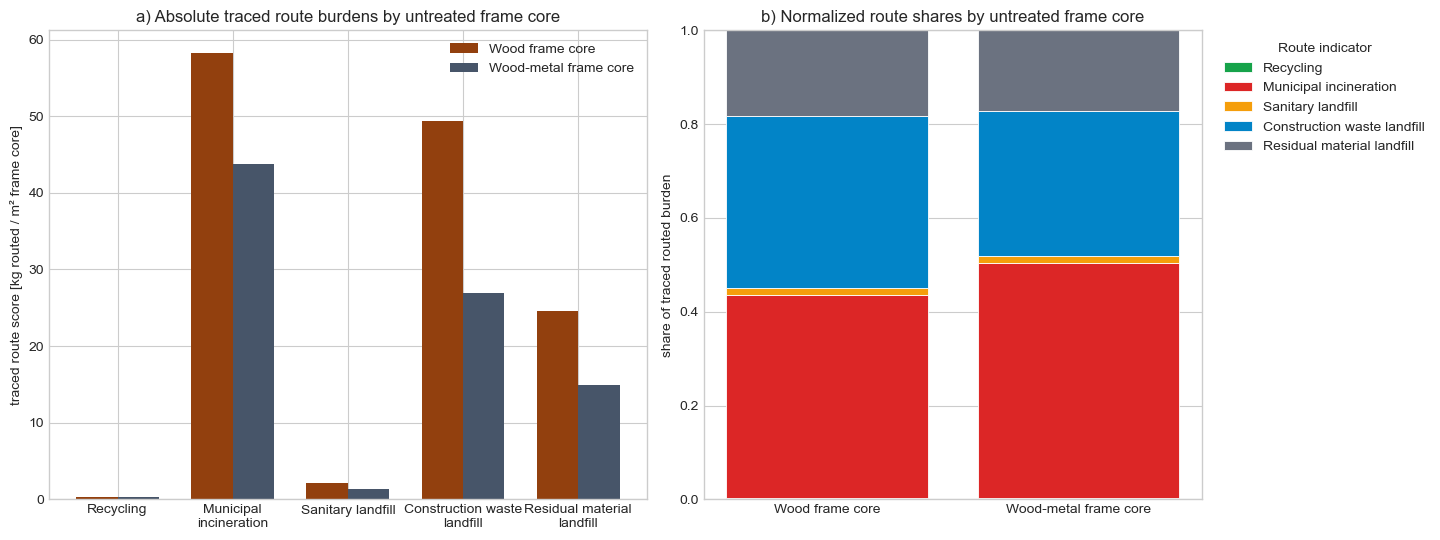

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5), gridspec_kw={'width_ratios': [1.2, 1.0]})

# a) Absolute routed burdens.
ax = axes[0]
x = np.arange(len(route_order))
width = 0.36
for offset, frame_label in zip([-width / 2, width / 2], window_frame_order):
    values = window_route_pivot.loc[frame_label, route_order].to_numpy(dtype=float)
    ax.bar(
        x + offset,
        values,
        width,
        label=frame_label,
        color=TREATMENT_SYSTEM_COLORS[frame_label],
        edgecolor='none',
    )
ax.set_xticks(x)
ax.set_xticklabels([fill(route, 18) for route in route_order])
#ax.set_yscale('log')
ax.set_ylabel('traced route score [kg routed / m² frame core]')
ax.set_title('a) Absolute traced route burdens by untreated frame core')
ax.legend(frameon=False)

# b) Normalized route shares.
ax = axes[1]
bottom = np.zeros(len(window_frame_order))
for route_label in route_order:
    values = window_route_shares.loc[window_frame_order, route_label].to_numpy(dtype=float)
    ax.bar(
        window_frame_order,
        values,
        bottom=bottom,
        color=ROUTE_COLORS.get(route_label, '#9ca3af'),
        edgecolor='white',
        linewidth=0.6,
        label=route_label,
    )
    bottom += values
ax.set_ylim(0, 1.0)
ax.set_ylabel('share of traced routed burden')
ax.set_title('b) Normalized route shares by untreated frame core')
ax.legend(title='Route indicator', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


## 8) Use a Sankey diagram to explain the wood-metal frame result

The wood-metal frame core has a more mixed material recipe than the wood-only frame. A Sankey diagram for the `municipal incineration` route makes it easier to see which branches of the product system feed that route.


In [19]:
wood_metal_incineration_supply_chain = SupplyChain(
    activity=window_frame_specs['Wood-metal frame core']['activity'],
    method=str(route_method_paths['Municipal incineration']),
    amount=1,
    level=4,
    cutoff=0.001,
    cutoff_basis='total',
    collapse_markets=True,
)

wood_metal_incineration_total = wood_metal_incineration_supply_chain.bootstrap()
wood_metal_incineration_df, _, _ = wood_metal_incineration_supply_chain.calculate()

wood_metal_incineration_df[[
    'level',
    'name',
    'location',
    'unit',
    'score',
    'share_of_total',
]].head(12)


Finding direct matches        [1/5]


,level,name,location,unit,score,share_of_total
0,0,"Window frame, wood-metal, w/o surface treatmen...",CH,square meter,4.369973e+01,1.000000e+00
1,1,Direct emissions/Res. use,None,None,4.107788e+01,9.400029e-01
2,1,activities below cutoff,None,None,1.568899e-01,3.590180e-03
3,1,"Disposal, plastics containing nitrogen (ABS, P...",CH,kilogram,5.968939e-02,1.365898e-03
4,2,Direct emissions/Res. use,None,None,-1.043092e-09,-2.386952e-11
5,2,activities below cutoff,None,None,1.390298e-06,3.181478e-08
6,2,"Disposal, plastics containing nitrogen (PU, po...",CH,kilogram,5.968800e-02,1.365866e-03
7,3,Direct emissions/Res. use,None,None,5.965789e-02,1.365178e-03
8,3,activities below cutoff,None,None,3.010623e-05,6.889339e-07
9,1,Metal working factory,RER,unit,1.281344e+00,2.932154e-02


Saved Sankey to D3-04_wood_metal_frame_incineration_sankey.html


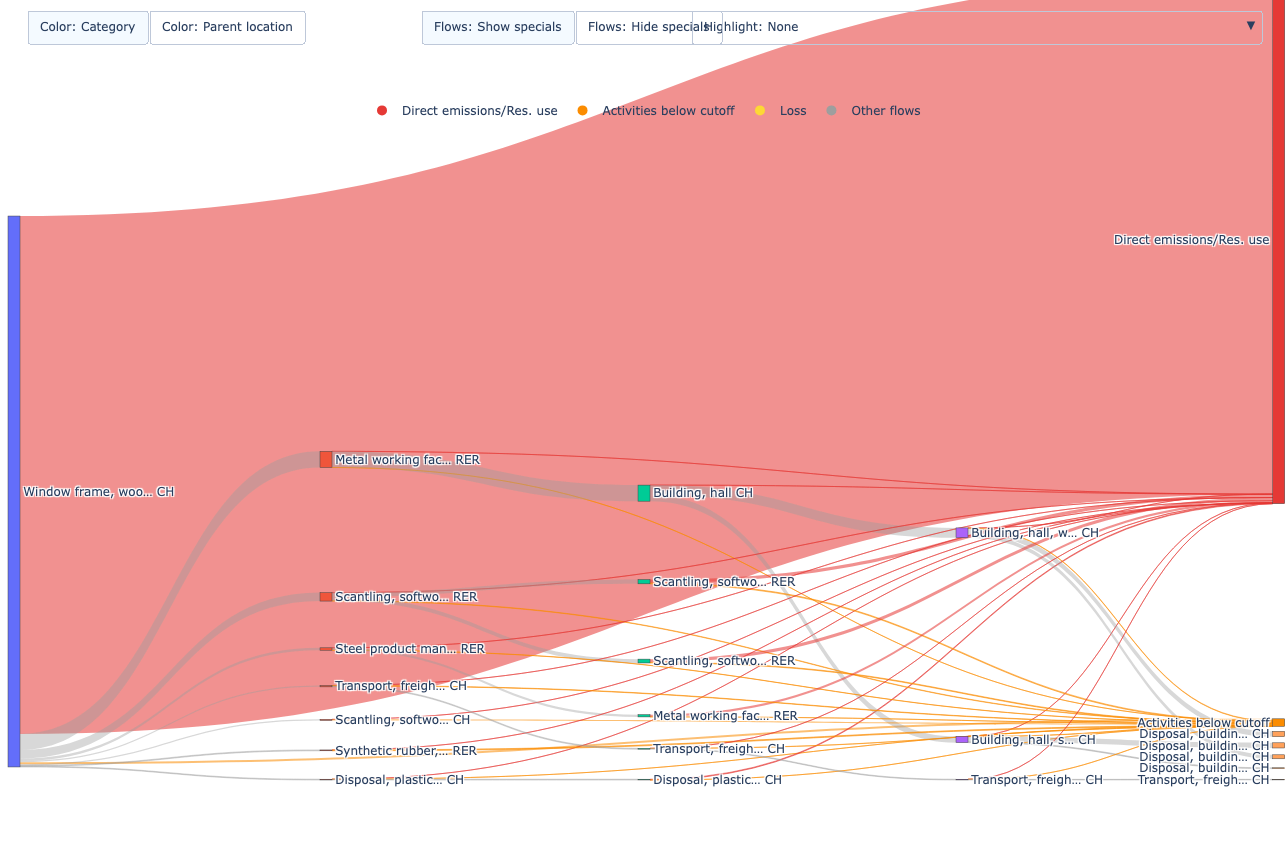

In [20]:
wood_metal_sankey_path = NOTEBOOK_DIR / 'D3-04_wood_metal_frame_incineration_sankey.html'

wood_metal_incineration_sankey = wood_metal_incineration_supply_chain.plot_sankey(
    wood_metal_incineration_df,
    width_max=1600,
    height_max=850,
    node_instance_mode='by_parent',
    node_thickness=12,
    node_pad=8,
)

wood_metal_incineration_sankey.write_html(wood_metal_sankey_path, include_plotlyjs='cdn')
print(f'Saved Sankey to {wood_metal_sankey_path}')
wood_metal_incineration_sankey


## Recap

After this notebook, you should now be able to:

- define custom `edges` methods that trace **technosphere intermediates** rather than biosphere emissions
- use `CF = 1.0` to turn matched exchanges into direct inventory-flow tracers
- compare **direct** and **full supply-chain** electricity requirements for two hydrogen routes
- build simple material-tracking indicators to compare wood-, steel-, aluminium-, and concrete-related burdens across two hydrogen systems
- use product systems that already embed end-of-life assumptions to study how material fractions are routed into treatment activities
- inspect the immediate `Disposal...` and `Treatment...` exchanges of a product system to identify its main material fractions
- build several route indicators to compare how two untreated window-frame cores feed incineration, recycling, and landfill routes
- use Sankey diagrams to explain both an upstream electricity result and a downstream treatment-route result

In `D3-05`, we will build on the same idea but replace the simple `1.0` tracking factor with **criticality factors** for selected intermediates.
